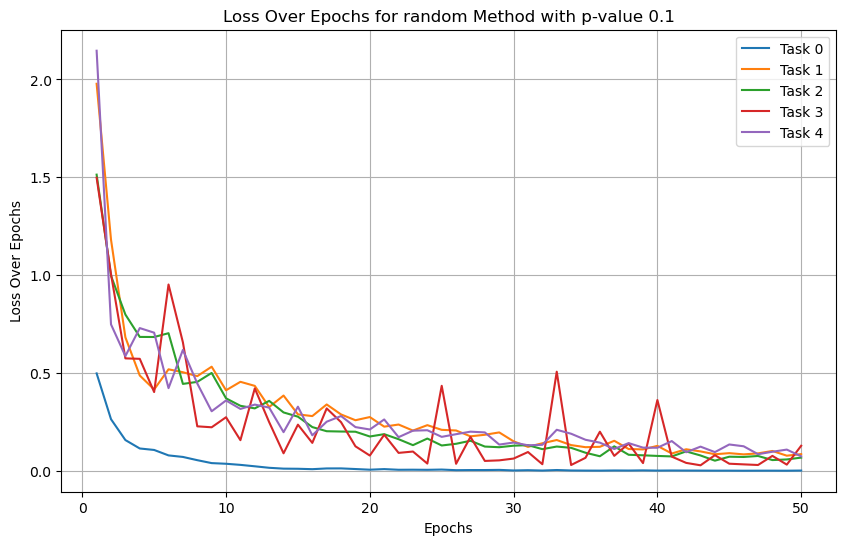

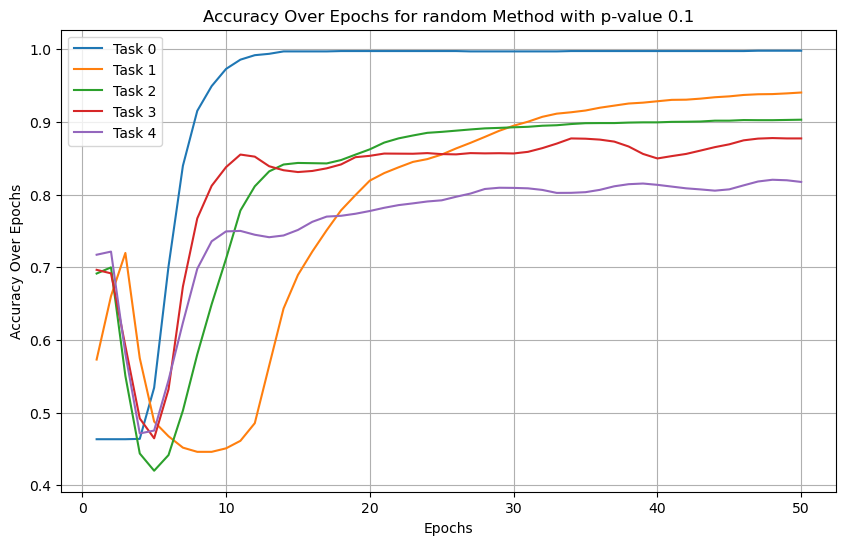

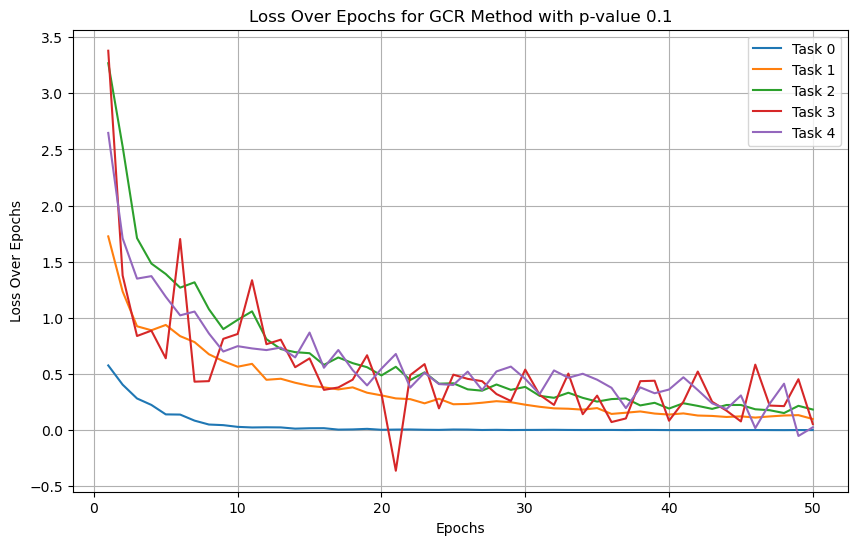

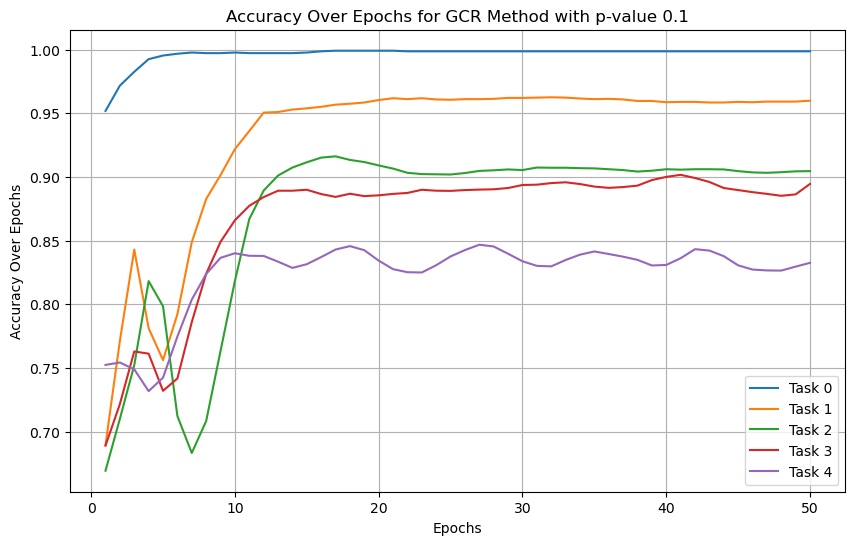

In [66]:
import numpy as np
import matplotlib.pyplot as plt

p_values = [0.1]
dataset_name = 'mnist_split'
grad_type = 'past'
method_arr = ['random', 'GCR']
metrics = ['loss_over_epochs', 'accuracy_over_epochs']  # These represent numpy arrays
tasks = [0, 1, 2, 3, 4]

for p_value in p_values:
    for method in method_arr:
        for metric in metrics:
            plt.figure(figsize=(10, 6))
            for task_no in tasks:
                # Construct the path to the numpy file
                path = f"models/{dataset_name}/{method}/{p_value}/train_0/task_{task_no}/{metric}.npy"
                
                # Load the numpy array
                metric_array = np.load(path)
                
                # Plot the metric array
                epochs = np.arange(1, len(metric_array) + 1)
                plt.plot(epochs, metric_array, label=f'Task {task_no}')
            
            # Add title and labels
            plt.title(f'{metric.replace("_", " ").title()} for {method} Method with p-value {p_value}')
            plt.xlabel('Epochs')
            plt.ylabel(metric.replace("_", " ").title())
            plt.legend()
            plt.grid(True)
            
            # # Save the plot
            # output_path = f"plots/{dataset_name}_{p_value}_{method}_{metric}.png"
            # plt.savefig(output_path)
            # plt.close()


In [ ]:
# Training a network on the data:

Visualized samples for Task 0
Visualized samples for Task 1
Visualized samples for Task 2
Visualized samples for Task 3
Visualized samples for Task 4


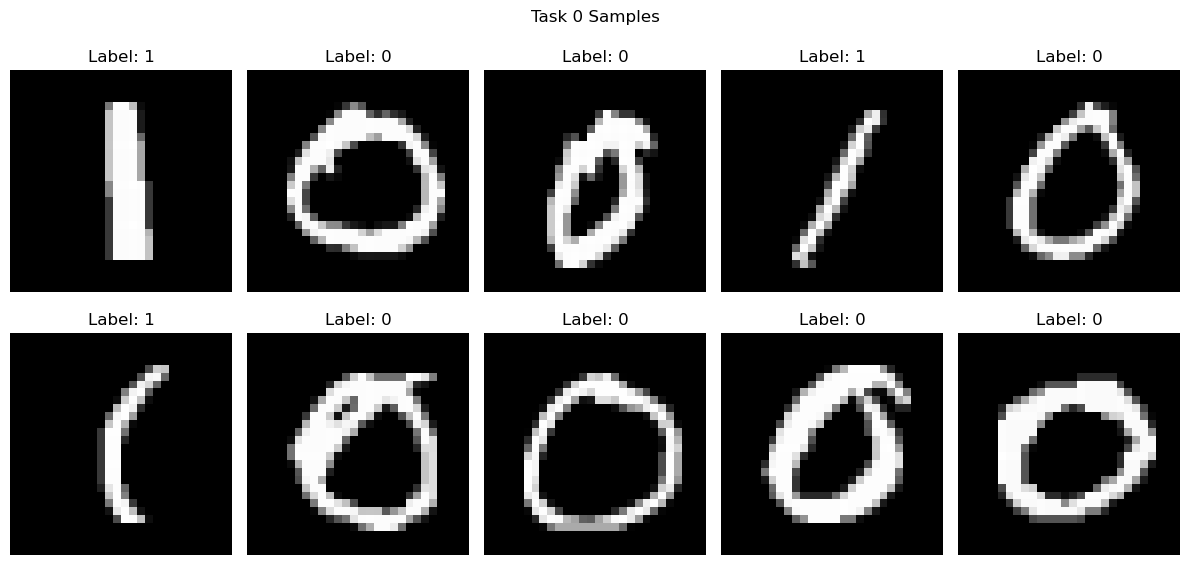

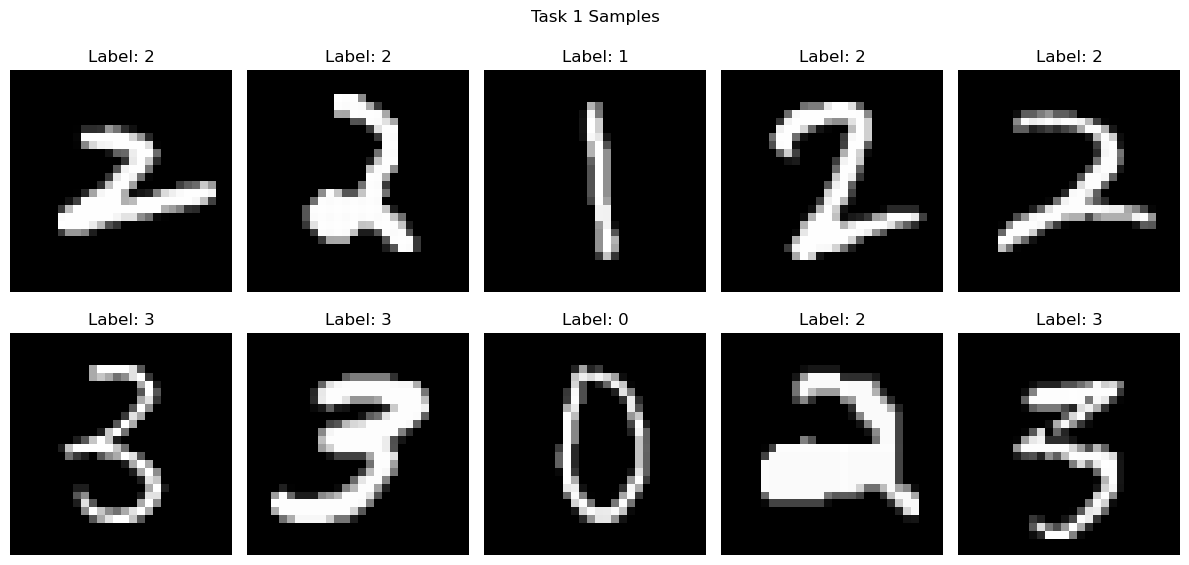

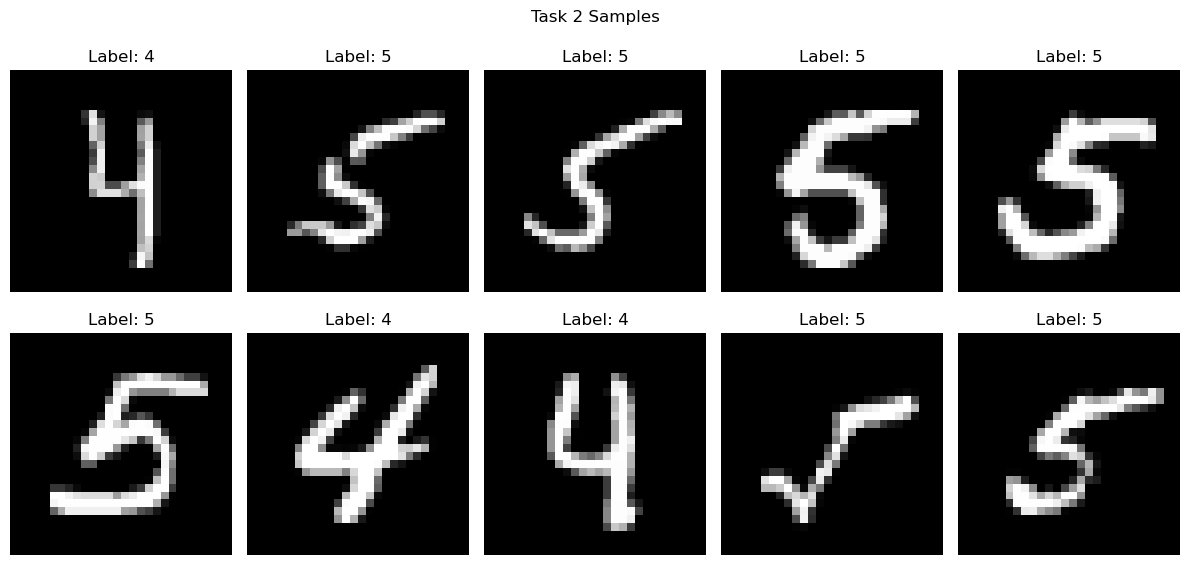

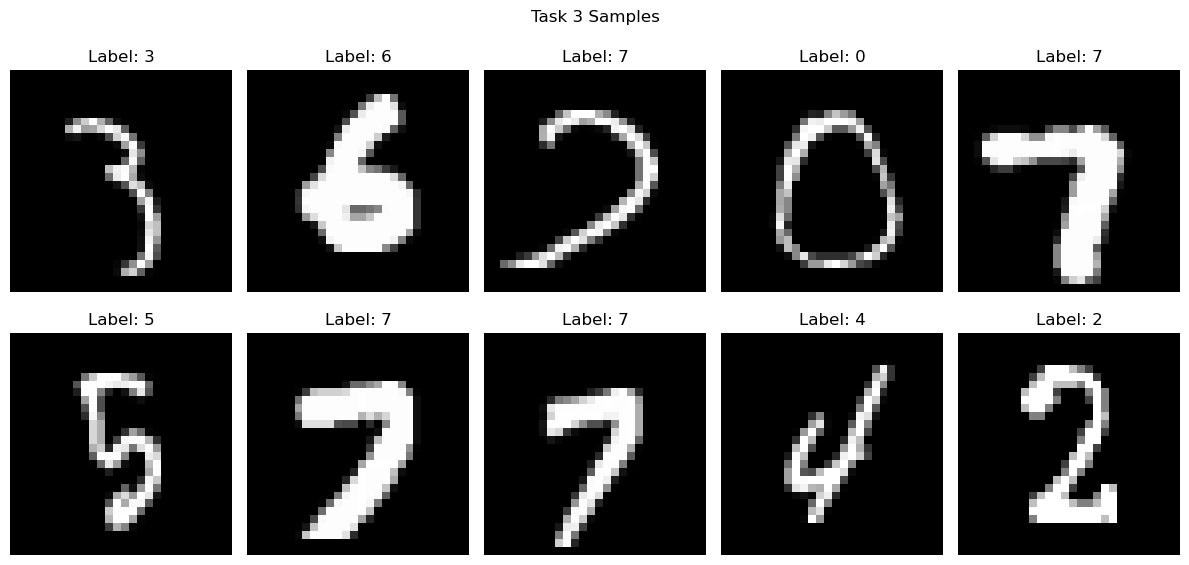

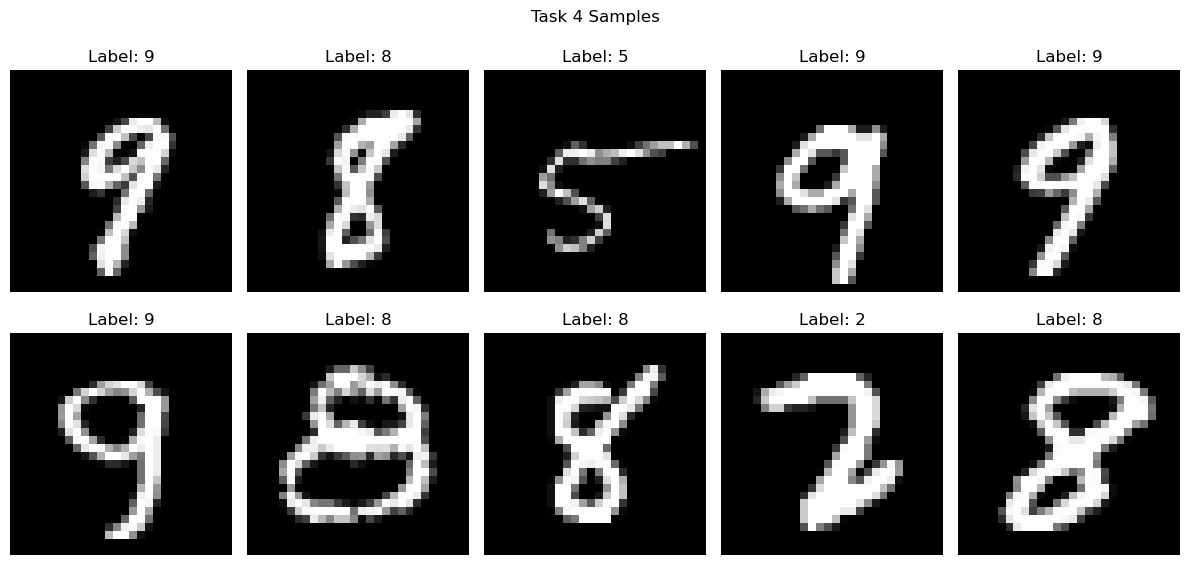

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(task_no, data_type='train', method='GCR', p_value=0.1):
    path = f"models/mnist_split/{method}/{p_value}/train_0/task_{task_no}/{data_type}_set.npy"
    data = np.load(path)
    features, labels = data[:, :-1], data[:, -1].astype(np.int64)
    return features, labels

def visualize_task_samples(task_no, num_samples=10):
    features, labels = load_data(task_no, 'train')
    
    # Randomly select samples
    indices = np.random.choice(len(features), num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle(f'Task {task_no} Samples')
    
    for i, idx in enumerate(indices):
        img = features[idx].reshape(28, 28)
        ax = axes[i // 5, i % 5]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label: {labels[idx]}')
        ax.axis('off')
    
    plt.tight_layout()
    # plt.savefig(f'task_{task_no}_samples.png')

def visualize_all_samples(task_no):
    features, labels = load_data(task_no, 'train')
    num_samples = len(features)
    rows = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(rows, rows, figsize=(20, 20))
    fig.suptitle(f'All Samples for Task {task_no}')
    
    for i in range(num_samples):
        img = features[i].reshape(28, 28)
        ax = axes[i // rows, i % rows]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label: {labels[i]}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'all_samples_task_{task_no}.png', dpi=300)
    
def visualize_all_tasks():
    for task_no in range(5):
        visualize_task_samples(task_no) #uncomment to visualize everything. 
        # visualize_all_samples(task_no)
        print(f"Visualized samples for Task {task_no}")


visualize_all_tasks()

In [71]:
method = 'random'
p_value = 0.1
acc = np.load(f"models/mnist_split/{method}/{p_value}/train_0/acc.npy")
saved_acc = np.load(f"models/mnist_split/{method}/{p_value}/train_0/acc_saved_memory_set.npy")
# print("Random Training accuracy", acc)
# print("Random Saved Set accuracy", saved_acc)

In [72]:
method = 'GCR'
p_value = 0.1
acc = np.load(f"models/mnist_split/{method}/{p_value}/train_0/acc.npy")
saved_acc = np.load(f"models/mnist_split/{method}/{p_value}/train_0/acc_saved_memory_set.npy")
print("GCR Training accuracy", acc)
print("GCR Saved Set accuracy", saved_acc)

GCR Training accuracy [0.99858156 0.9598268  0.90449345 0.89447424 0.8325    ]
GCR Saved Set accuracy [0.99810875 0.93408708 0.89222351 0.8521891  0.7857    ]


In [73]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random

class MLP(nn.Module):
    def __init__(self, sizes, acts):
        if len(sizes) != len(acts) + 2:
            raise ValueError(f"length of sizes ({len(sizes)}) and activations ({len(acts)}) are incompatible")
        super().__init__()
        self.num_layers = len(sizes) - 1
        lower_modules = []
        for i in range(self.num_layers - 1):
            lower_modules.append(nn.Linear(sizes[i], sizes[i + 1]))
            if acts[i] == "relu":
                lower_modules.append(nn.ReLU())
            elif acts[i] == "sigmoid":
                lower_modules.append(nn.Sigmoid())
            else:
                raise ValueError(f"{acts[i]} activation layer hasn't been implemented in this code")
        self.layers = nn.Sequential(*lower_modules)
        self.output_layer = nn.Linear(sizes[-2], sizes[-1])

    def forward(self, x, return_preactivations=False):
        pre_o = self.layers(x)
        o = self.output_layer(pre_o)
        if not return_preactivations:
            return o
        return o, pre_o

def load_data(task_no, method='GCR', p_value=0.1):
    train_path = f"models/mnist_split/{method}/{p_value}/train_0/task_{task_no}/train_set.npy"
    test_path = f"models/mnist_split/{method}/{p_value}/train_0/task_{task_no}/test_set.npy"
    
    train_data = np.load(train_path)
    test_data = np.load(test_path)
    
    train_features, train_labels = train_data[:, :-1], train_data[:, -1].astype(np.int64)
    test_features, test_labels = test_data[:, :-1], test_data[:, -1].astype(np.int64)
    
    return train_features, train_labels, test_features, test_labels

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    for batch in train_loader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return correct / total

# def main():
#     # Set random seed
#     random_seed = 0xC0FFEE
#     torch.manual_seed(random_seed)
#     np.random.seed(random_seed)
#     random.seed(random_seed)

#     # Hyperparameters
#     lr = 0.001
#     batch_size = 256
#     epochs = 50
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#     # Create model
#     model = MLP(sizes=[784, 100, 10], acts=['relu']).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()

#     # Train and evaluate on each task
#     for task_no in range(5):
#         print(f"Training on Task {task_no}")
        
#         # Load data for the current task
#         train_features, train_labels, test_features, test_labels = load_data(task_no)
        
#         # Create DataLoaders
#         train_dataset = TensorDataset(torch.FloatTensor(train_features), torch.LongTensor(train_labels))
#         test_dataset = TensorDataset(torch.FloatTensor(test_features), torch.LongTensor(test_labels))
#         train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#         test_loader = DataLoader(test_dataset, batch_size=batch_size)

#         # Train the model
#         for epoch in range(epochs):
#             train(model, train_loader, optimizer, criterion, device)
        
#         # Evaluate on all tasks
#         for eval_task in range(task_no + 1):
#             _, _, eval_features, eval_labels = load_data(eval_task)
#             eval_dataset = TensorDataset(torch.FloatTensor(eval_features), torch.LongTensor(eval_labels))
#             eval_loader = DataLoader(eval_dataset, batch_size=batch_size)
#             accuracy = evaluate(model, eval_loader, device)
#             print(f"  Accuracy on Task {eval_task}: {accuracy:.4f}")

def main():
    # Set random seed
    random_seed = 0xC0FFEE
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Hyperparameters
    lr = 0.001
    batch_size = 256
    epochs = 50
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create model
    model = MLP(sizes=[784, 100, 10], acts=['relu']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # List to store accuracies of each task when first trained
    first_train_accuracies = []

    # Train and evaluate on each task
    for task_no in range(5):
        print(f"Training on Task {task_no}")
        
        # Load data for the current task
        train_features, train_labels, test_features, test_labels = load_data(task_no)
        
        # Create DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(train_features), torch.LongTensor(train_labels))
        test_dataset = TensorDataset(torch.FloatTensor(test_features), torch.LongTensor(test_labels))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        # Train the model
        for epoch in range(epochs):
            train(model, train_loader, optimizer, criterion, device)
        
        # Evaluate on all tasks
        for eval_task in range(task_no + 1):
            _, _, eval_features, eval_labels = load_data(eval_task)
            eval_dataset = TensorDataset(torch.FloatTensor(eval_features), torch.LongTensor(eval_labels))
            eval_loader = DataLoader(eval_dataset, batch_size=batch_size)
            accuracy = evaluate(model, eval_loader, device)
            print(f"  Accuracy on Task {eval_task}: {accuracy:.4f}")
            
            # Save accuracy of the current task
            if eval_task == task_no:
                first_train_accuracies.append(accuracy)

    # Print the additional results
    print(f"Random Saved Set accuracy {first_train_accuracies}")

if __name__ == "__main__":
    main()

if __name__ == "__main__":
    main()

Training on Task 0
  Accuracy on Task 0: 0.9986
Training on Task 1
  Accuracy on Task 0: 0.8071
  Accuracy on Task 1: 0.8836
Training on Task 2
  Accuracy on Task 0: 0.6520
  Accuracy on Task 1: 0.5853
  Accuracy on Task 2: 0.7067
Training on Task 3
  Accuracy on Task 0: 0.8170
  Accuracy on Task 1: 0.7825
  Accuracy on Task 2: 0.7209
  Accuracy on Task 3: 0.7851
Training on Task 4
  Accuracy on Task 0: 0.8610
  Accuracy on Task 1: 0.7842
  Accuracy on Task 2: 0.6443
  Accuracy on Task 3: 0.6658
  Accuracy on Task 4: 0.7211
Random Saved Set accuracy [0.9985815602836879, 0.8835698821265335, 0.7066821422649644, 0.7850817013845578, 0.7211]
Training on Task 0
  Accuracy on Task 0: 0.9986
Training on Task 1
  Accuracy on Task 0: 0.8071
  Accuracy on Task 1: 0.8836
Training on Task 2
  Accuracy on Task 0: 0.6520
  Accuracy on Task 1: 0.5853
  Accuracy on Task 2: 0.7067
Training on Task 3
  Accuracy on Task 0: 0.8170
  Accuracy on Task 1: 0.7825
  Accuracy on Task 2: 0.7209
  Accuracy on Task

In [74]:
class MLP(nn.Module):
    def __init__(self, sizes, acts):
        if len(sizes) != len(acts) + 2:
            raise ValueError(f"length of sizes ({len(sizes)}) and activations ({len(acts)}) are incompatible")
        super().__init__()
        self.num_layers = len(sizes) - 1
        lower_modules = []
        for i in range(self.num_layers - 1):
            lower_modules.append(nn.Linear(sizes[i], sizes[i + 1]))
            if acts[i] == "relu":
                lower_modules.append(nn.ReLU())
            elif acts[i] == "sigmoid":
                lower_modules.append(nn.Sigmoid())
            else:
                raise ValueError(f"{acts[i]} activation layer hasn't been implemented in this code")
        self.layers = nn.Sequential(*lower_modules)
        self.output_layer = nn.Linear(sizes[-2], sizes[-1])

    def forward(self, x, return_preactivations=False):
        pre_o = self.layers(x)
        o = self.output_layer(pre_o)
        if not return_preactivations:
            return o
        return o, pre_o

def load_data(task_no, method='random', p_value=0.1):
    train_path = f"models/mnist_split/{method}/{p_value}/train_0/task_{task_no}/train_set.npy"
    test_path = f"models/mnist_split/{method}/{p_value}/train_0/task_{task_no}/test_set.npy"
    
    train_data = np.load(train_path)
    test_data = np.load(test_path)
    
    # For both random and GCR, we'll use all columns except the last as features
    train_features, train_labels = train_data[:, :-1], train_data[:, -1].astype(np.int64)
    test_features, test_labels = test_data[:, :-1], test_data[:, -1].astype(np.int64)
    
    return train_features, train_labels, test_features, test_labels

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    for batch in train_loader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return correct / total

def main():
    # Set random seed
    random_seed = 0xC0FFEE
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Hyperparameters
    lr = 0.001
    batch_size = 256
    epochs = 50
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    method = 'GCR'  # Change this to 'random' when using random method

    # Create model
    model = MLP(sizes=[784, 100, 10], acts=['relu']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate on each task
    for task_no in range(5):
        print(f"Training on Task {task_no}")
        
        # Load data for the current task
        train_features, train_labels, test_features, test_labels = load_data(task_no, method=method)
        
        # Create DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(train_features), torch.LongTensor(train_labels))
        test_dataset = TensorDataset(torch.FloatTensor(test_features), torch.LongTensor(test_labels))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        # Train the model
        for epoch in range(epochs):
            train(model, train_loader, optimizer, criterion, device)
        
        # Evaluate on all tasks
        for eval_task in range(task_no + 1):
            _, _, eval_features, eval_labels = load_data(eval_task, method=method)
            eval_dataset = TensorDataset(torch.FloatTensor(eval_features), torch.LongTensor(eval_labels))
            eval_loader = DataLoader(eval_dataset, batch_size=batch_size)
            accuracy = evaluate(model, eval_loader, device)
            print(f"  Accuracy on Task {eval_task}: {accuracy:.4f}")

if __name__ == "__main__":
    main()


Training on Task 0
  Accuracy on Task 0: 0.9986
Training on Task 1
  Accuracy on Task 0: 0.7305
  Accuracy on Task 1: 0.8451
Training on Task 2
  Accuracy on Task 0: 0.5324
  Accuracy on Task 1: 0.4770
  Accuracy on Task 2: 0.6321
Training on Task 3
  Accuracy on Task 0: 0.8979
  Accuracy on Task 1: 0.7390
  Accuracy on Task 2: 0.7105
  Accuracy on Task 3: 0.7754
Training on Task 4
  Accuracy on Task 0: 0.8416
  Accuracy on Task 1: 0.7351
  Accuracy on Task 2: 0.5787
  Accuracy on Task 3: 0.6207
  Accuracy on Task 4: 0.6854
